In [1]:
"""
================================================================================
D-HNN para Sistema ORC (Organic Rankine Cycle)
================================================================================
Implementación de Dissipative Hamiltonian Neural Networks (D-HNNs) aplicada
al modelado dinámico de un Ciclo Rankine Orgánico.

Basado en:
  - Sosanya & Greydanus (2022). "Dissipative Hamiltonian Neural Networks:
    Learning Dissipative and Conservative Dynamics Separately." arXiv:2201.10085
  - Quoilin et al. (2011). "Dynamic modeling and optimal control strategy
    of waste heat recovery organic rankine cycles." Applied Energy.

Pipeline:
  Ecuaciones ORC → Generación de datos (x, dx/dt) → Separación (q, p)
  → D-HNN [H(q,p) + D(q,p)] → Gradientes (autograd) → Predicción dx/dt
  → Loss vs física real → Entrenamiento → Simulación temporal
  → Interpretación física

Coordenadas canónicas del sistema ORC:
  q = Tevap(t)  → Temperatura del evaporador  [coordenada de posición generalizada]
  p = Tcond(t)  → Temperatura del condensador  [coordenada de momento generalizado]

Variables auxiliares (no canónicas, incluidas como entradas adicionales):
  m_dot(t)     → Tasa de flujo másico

Autor: Maria Isabel García Quimbayo
Tema: Simulación D-HNN ORC
Fecha: 2025
================================================================================
"""

# ==============================================================================
# 1. IMPORTACIONES
# ==============================================================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Dispositivo de cómputo
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de cómputo: {DISPOSITIVO}")

# ==============================================================================
# DIRECTORIO DE SALIDA
# Funciona automáticamente en Google Colab, Jupyter local o cualquier entorno.
# Las figuras se guardan en la carpeta 'resultados_dhnn_orc/' junto al script.
# ==============================================================================
DIR_SALIDA = os.path.join(os.getcwd(), 'resultados_dhnn_orc')
os.makedirs(DIR_SALIDA, exist_ok=True)
print(f"[INFO] Figuras se guardarán en: {DIR_SALIDA}")

[INFO] Dispositivo de cómputo: cpu
[INFO] Figuras se guardarán en: /content/resultados_dhnn_orc


In [2]:
# ==============================================================================
# 2. PARÁMETROS FÍSICOS DEL SISTEMA ORC
# ==============================================================================

class ParametrosORC:
    """
    Parámetros físicos del sistema ORC.

    Variables del sistema:
      - Tevap(t): Temperatura del evaporador [K]
      - Tcond(t): Temperatura del condensador [K]
      - m_dot(t): Tasa de flujo másico [kg/s]

    Parámetros del fluido orgánico (R245fa como referencia):
      - Cp:   Capacidad calorífica específica [kJ/(kg·K)]
      - rho:  Densidad del fluido [kg/m³]

    Constantes de diseño:
      - UA_evap:  Coeficiente global × área del evaporador [kW/K]
      - UA_cond:  Coeficiente global × área del condensador [kW/K]
      - C_evap:   Capacitancia térmica del evaporador [kJ/K]
      - C_cond:   Capacitancia térmica del condensador [kJ/K]
      - eta_turb: Eficiencia isentrópica de la turbina [-]
      - tau_pump: Constante de tiempo de la bomba [s]
      - T_source: Temperatura de la fuente de calor [K]
      - T_sink:   Temperatura del sumidero de calor [K]
      - m_target: Flujo másico objetivo [kg/s]
    """
    # --- Fluido orgánico (R245fa) ---
    Cp      = 1.30    # kJ/(kg·K)  - Capacidad calorífica
    rho     = 1330.0  # kg/m³      - Densidad

    # --- Condiciones de frontera ---
    T_source = 423.15  # K  (~150°C)  - Temperatura de la fuente
    T_sink   = 303.15  # K  (~30°C)   - Temperatura del sumidero

    # --- Coeficientes de intercambio de calor ---
    UA_evap  = 2.5    # kW/K
    UA_cond  = 2.0    # kW/K

    # --- Capacitancias térmicas (inercia térmica) ---
    C_evap   = 50.0   # kJ/K  - Masa térmica del evaporador
    C_cond   = 40.0   # kJ/K  - Masa térmica del condensador

    # --- Parámetros de la turbina y bomba ---
    eta_turb = 0.80   # [-]   - Eficiencia isentrópica
    tau_pump = 5.0    # s     - Constante de tiempo de la bomba

    # --- Punto de operación ---
    m_target = 0.5    # kg/s  - Flujo másico objetivo

    # --- Estado inicial ---
    Tevap_0  = 380.0  # K     - Temperatura inicial del evaporador
    Tcond_0  = 320.0  # K     - Temperatura inicial del condensador
    m_dot_0  = 0.3    # kg/s  - Flujo másico inicial

In [3]:
# ==============================================================================
# 3. MODELO FÍSICO DEL ORC (Ecuaciones Diferenciales)
# ==============================================================================

def orc_derivadas(t, estado, params):
    """
    Calcula las derivadas temporales del sistema ORC.

    Ecuaciones del modelo:
    -----------------------------------------------------------------------
    (1) Evaporador (balance de energía):
        C_evap · dTevap/dt = UA_evap·(T_source - Tevap) - m_dot·Cp·(Tevap - Tcond)

    (2) Condensador (balance de energía):
        C_cond · dTcond/dt = m_dot·Cp·(Tevap - Tcond)·(1-eta) - UA_cond·(Tcond - T_sink)

    (3) Bomba (balance de momento):
        tau · dm_dot/dt = m_target - m_dot

    Parámetros:
    -----------
    t      : float     - Tiempo actual [s]
    estado : array     - [Tevap, Tcond, m_dot]
    params : ParametrosORC - Parámetros físicos

    Retorna:
    --------
    lista : [dTevap/dt, dTcond/dt, dm_dot/dt]
    """
    Tevap, Tcond, m_dot = estado

    p = params  # alias corto

    # Ecuación 1: Evaporador
    calor_entrada  = p.UA_evap * (p.T_source - Tevap)
    energia_salida = m_dot * p.Cp * (Tevap - Tcond)
    dTevap_dt = (calor_entrada - energia_salida) / p.C_evap

    # Ecuación 2: Condensador
    calor_residual  = m_dot * p.Cp * (Tevap - Tcond) * (1.0 - p.eta_turb)
    calor_rechazado = p.UA_cond * (Tcond - p.T_sink)
    dTcond_dt = (calor_residual - calor_rechazado) / p.C_cond

    # Ecuación 3: Dinámica de la bomba
    dm_dot_dt = (p.m_target - m_dot) / p.tau_pump

    return [dTevap_dt, dTcond_dt, dm_dot_dt]


def potencia_electrica(Tevap, Tcond, m_dot, params):
    """
    Calcula la potencia eléctrica generada por la turbina (ecuación algebraica).

    P_elec(t) = m_dot · Cp · (Tevap - Tcond) · eta_turb

    Parámetros:
    -----------
    Tevap, Tcond, m_dot : float o array
    params : ParametrosORC

    Retorna:
    --------
    P_elec : float o array [kW]
    """
    return m_dot * params.Cp * (Tevap - Tcond) * params.eta_turb

In [4]:
# ==============================================================================
# 4. GENERACIÓN DE DATOS DE ENTRENAMIENTO
# ==============================================================================

def generar_datos_orc(params, t_span=(0, 200), n_puntos=2000, ruido=0.01):
    """
    Integra el sistema ORC y genera el conjunto de datos (estado, derivadas).

    La solución numérica usa Runge-Kutta de orden 5 (RK45).

    Parámetros:
    -----------
    params   : ParametrosORC
    t_span   : tupla (t_inicio, t_fin) [s]
    n_puntos : int    - Número de puntos de muestreo
    ruido    : float  - Desviación estándar del ruido gaussiano (fracción relativa)

    Retorna:
    --------
    datos : dict con claves:
        't'         : array (N,)     - Vector de tiempo
        'estados'   : array (N, 3)   - [Tevap, Tcond, m_dot]
        'derivadas' : array (N, 3)   - [dTevap/dt, dTcond/dt, dm_dot/dt]
        'potencia'  : array (N,)     - Potencia eléctrica generada [kW]
    """
    print("[INFO] Integrando sistema ORC con RK45...")

    estado_inicial = [params.Tevap_0, params.Tcond_0, params.m_dot_0]
    t_eval = np.linspace(t_span[0], t_span[1], n_puntos)

    # Integración numérica con tolerancia estricta
    sol = solve_ivp(
        fun=lambda t, y: orc_derivadas(t, y, params),
        t_span=t_span,
        y0=estado_inicial,
        method='RK45',
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    estados   = sol.y.T                    # (N, 3)
    derivadas = np.array([
        orc_derivadas(t, estado, params)
        for t, estado in zip(sol.t, estados)
    ])                                     # (N, 3)

    # Agregar ruido gaussiano para simular mediciones reales
    if ruido > 0:
        for i in range(estados.shape[1]):
            escala = ruido * np.std(estados[:, i])
            estados[:, i]   += np.random.normal(0, escala, estados.shape[0])
            escala_d = ruido * np.std(derivadas[:, i])
            derivadas[:, i] += np.random.normal(0, escala_d, derivadas.shape[0])

    potencia = potencia_electrica(
        estados[:, 0], estados[:, 1], estados[:, 2], params
    )

    print(f"[INFO] Datos generados: {n_puntos} puntos en [{t_span[0]}, {t_span[1]}] s")
    print(f"[INFO] Tevap rango: [{estados[:,0].min():.1f}, {estados[:,0].max():.1f}] K")
    print(f"[INFO] Tcond rango: [{estados[:,1].min():.1f}, {estados[:,1].max():.1f}] K")
    print(f"[INFO] Potencia media: {potencia.mean():.3f} kW")

    return {
        't': sol.t,
        'estados': estados,
        'derivadas': derivadas,
        'potencia': potencia
    }


def normalizar_datos(datos):
    """
    Normaliza las entradas al rango [-1, 1] para mejorar el entrenamiento.

    Retorna los datos normalizados y los parámetros de normalización
    necesarios para desnormalizar posteriormente.

    Parámetros:
    -----------
    datos : dict con 'estados' y 'derivadas'

    Retorna:
    --------
    estados_norm   : array normalizado
    derivadas_norm : array normalizado
    media          : array de medias por columna
    escala         : array de escalas (desviación estándar) por columna
    """
    media  = datos['estados'].mean(axis=0)
    escala = datos['estados'].std(axis=0)
    escala[escala < 1e-8] = 1.0  # Evitar división por cero

    estados_norm   = (datos['estados']   - media) / escala
    derivadas_norm = datos['derivadas'] / escala  # Solo escalar derivadas

    return estados_norm, derivadas_norm, media, escala

In [5]:
# ==============================================================================
# 5. ARQUITECTURA D-HNN
# ==============================================================================

class SubredEscalar(nn.Module):
    """
    Subred neuronal que mapea coordenadas canónicas (q, p) a un escalar.

    Arquitectura: MLP con activaciones tanh y una capa residual.
    Se usa tanh porque es diferenciable en todas partes (requerimiento de autograd).

    Parámetros:
    -----------
    dim_entrada  : int - Dimensión del vector de entrada
    dim_oculta   : int - Número de neuronas en capas ocultas
    """
    def __init__(self, dim_entrada=3, dim_oculta=128):
        super().__init__()

        # Capa de entrada
        self.capa_entrada = nn.Linear(dim_entrada, dim_oculta)

        # Capa oculta principal
        self.capa_oculta = nn.Linear(dim_oculta, dim_oculta)

        # Capa residual (permite gradientes más estables)
        self.capa_residual = nn.Linear(dim_oculta, dim_oculta)

        # Capa de salida (escalar)
        self.capa_salida = nn.Linear(dim_oculta, 1)

        # Inicialización Xavier para mejor convergencia
        for capa in [self.capa_entrada, self.capa_oculta,
                     self.capa_residual, self.capa_salida]:
            nn.init.xavier_normal_(capa.weight)
            nn.init.zeros_(capa.bias)

    def forward(self, x):
        """
        Propagación hacia adelante.

        x : tensor (batch, dim_entrada) - Coordenadas [Tevap, Tcond, m_dot]
        """
        h = torch.tanh(self.capa_entrada(x))
        h_oculta = torch.tanh(self.capa_oculta(h))
        h = h + torch.tanh(self.capa_residual(h_oculta))  # conexión residual
        return self.capa_salida(h)                         # escalar


class DHNN_ORC(nn.Module):
    """
    Dissipative Hamiltonian Neural Network para el sistema ORC.

    Arquitectura (según Fig. 1 de Sosanya & Greydanus, 2022):
    ──────────────────────────────────────────────────────────
                     ┌─────────────────┐
     (Tevap,          │  Subred D       │──→ D(q,p)
      Tcond,   ──────→│  (Disipativa)   │           ∂D/∂q, ∂D/∂p
      m_dot)          └─────────────────┘               ↓
                             ↓                     [gradiente regular]
                     ┌─────────────────┐                ↓
                     │  Subred H       │──→ H(q,p)  → Suma → dx/dt predicho
                     │  (Hamiltoniana) │           ∂H/∂p, -∂H/∂q
                     └─────────────────┘
                             ↑
                        [gradiente simpléctico]
    ──────────────────────────────────────────────────────────

    Función de pérdida (Ecuación 5 del paper):
        L = ||( ∂H/∂p + ∂D/∂q ) - dq/dt||² + ||(-∂H/∂q + ∂D/∂p) - dp/dt||²

    Mapeado al ORC:
        q ← Tevap (coordenada generalizada)
        p ← Tcond (momento generalizado)
        Entrada auxiliar: m_dot

    La dinámica de m_dot (bomba) es puramente disipativa (primer orden),
    por lo que se modela directamente con la componente disipativa D.

    Parámetros:
    -----------
    dim_oculta : int - Neuronas por capa en cada subred
    """
    def __init__(self, dim_oculta=128):
        super().__init__()

        # Subred Hamiltoniana: H(q, p, m_dot) → escalar conservativo
        self.subred_H = SubredEscalar(dim_entrada=3, dim_oculta=dim_oculta)

        # Subred Disipativa: D(q, p, m_dot) → escalar disipativo (función de Rayleigh)
        self.subred_D = SubredEscalar(dim_entrada=3, dim_oculta=dim_oculta)

    def forward(self, x):
        """
        Computa las derivadas predichas usando gradientes automáticos.

        Paso 1: Obtener H y D como funciones escalares.
        Paso 2: Calcular gradientes simbólicos (autograd de PyTorch).
        Paso 3: Combinar según la estructura Hamiltoniana-Rayleigh:
                dq/dt = ∂H/∂p  + ∂D/∂q
                dp/dt = -∂H/∂q + ∂D/∂p

        Parámetros:
        -----------
        x : tensor (batch, 3) con requires_grad=True
            Columnas: [Tevap_norm, Tcond_norm, m_dot_norm]

        Retorna:
        --------
        dx_dt : tensor (batch, 3) - derivadas predichas normalizadas
        H_val : tensor (batch, 1) - valores del Hamiltoniano
        D_val : tensor (batch, 1) - valores de la función de Rayleigh
        """
        # Asegurar que los gradientes fluyan hacia la entrada
        if not x.requires_grad:
            x = x.detach().requires_grad_(True)

        # ── Subred H ──────────────────────────────────────────────────────────
        H_val = self.subred_H(x)   # (batch, 1) - Hamiltoniano (conservativo)

        # Gradiente simpléctico de H respecto a la entrada completa
        # ∇H = [∂H/∂q, ∂H/∂p, ∂H/∂m_dot]  → índices [0, 1, 2]
        grad_H = torch.autograd.grad(
            outputs=H_val.sum(),
            inputs=x,
            create_graph=True   # necesario para diferenciación de segundo orden
        )[0]                    # (batch, 3)

        # ── Subred D ──────────────────────────────────────────────────────────
        D_val = self.subred_D(x)   # (batch, 1) - Función de Rayleigh (disipativo)

        # Gradiente regular de D respecto a la entrada completa
        grad_D = torch.autograd.grad(
            outputs=D_val.sum(),
            inputs=x,
            create_graph=True
        )[0]                    # (batch, 3)

        # ── Ecuaciones de movimiento combinadas ───────────────────────────────
        # Índices: 0=q(Tevap), 1=p(Tcond), 2=m_dot
        #
        # Estructura Hamiltoniana-Rayleigh:
        #   dq/dt =  ∂H/∂p  + ∂D/∂q  →  col 0 (Tevap)
        #   dp/dt = -∂H/∂q  + ∂D/∂p  →  col 1 (Tcond)
        #   dm/dt =           ∂D/∂m   →  col 2 (m_dot, solo disipativo)

        dq_dt = grad_H[:, 1:2]  + grad_D[:, 0:1]   # dTevap/dt
        dp_dt = -grad_H[:, 0:1] + grad_D[:, 1:2]   # dTcond/dt
        dm_dt =                   grad_D[:, 2:3]    # dm_dot/dt

        dx_dt = torch.cat([dq_dt, dp_dt, dm_dt], dim=1)  # (batch, 3)

        return dx_dt, H_val, D_val

    def energia_conservada(self, x):
        """
        Evalúa solo la componente conservativa H(q, p).
        Útil para análisis posterior del entrenamiento.
        """
        x_t = x.detach().requires_grad_(True)
        return self.subred_H(x_t).detach()

    def disipacion_rayleigh(self, x):
        """
        Evalúa solo la componente disipativa D(q, p).
        D > 0 implica pérdidas de energía (irreversibilidad).
        """
        x_t = x.detach().requires_grad_(True)
        return self.subred_D(x_t).detach()

In [6]:
# ==============================================================================
# 6. ENTRENAMIENTO
# ==============================================================================

def entrenar_dhnn(modelo, X_train, dX_train, X_test, dX_test,
                  n_epocas=5000, tasa_aprendizaje=1e-3, batch_size=128):
    """
    Entrenamiento de la D-HNN mediante descenso de gradiente (Adam).

    Función de pérdida (Ecuación 5 del paper):
        L_DHNN = ||(∂H/∂p + ∂D/∂q) - dq/dt||² + ||(-∂H/∂q + ∂D/∂p) - dp/dt||²

    Se utiliza la pérdida MSE (Error Cuadrático Medio) entre las derivadas
    predichas por la D-HNN y las derivadas reales del sistema ORC.

    Parámetros:
    -----------
    modelo         : DHNN_ORC
    X_train        : tensor (N_train, 3) - estados normalizados de entrenamiento
    dX_train       : tensor (N_train, 3) - derivadas normalizadas de entrenamiento
    X_test         : tensor (N_test, 3)  - estados de prueba
    dX_test        : tensor (N_test, 3)  - derivadas de prueba
    n_epocas       : int   - número de épocas
    tasa_aprendizaje: float
    batch_size     : int

    Retorna:
    --------
    historial : dict con 'perdida_train' y 'perdida_test' por época
    """
    optimizador = optim.Adam(modelo.parameters(), lr=tasa_aprendizaje)
    scheduler   = optim.lr_scheduler.StepLR(optimizador, step_size=1000, gamma=0.5)
    criterio    = nn.MSELoss()

    historial = {'perdida_train': [], 'perdida_test': []}

    n_train = X_train.shape[0]
    n_batches = max(1, n_train // batch_size)

    print(f"\n[INFO] Iniciando entrenamiento: {n_epocas} épocas, "
          f"lr={tasa_aprendizaje}, batch={batch_size}")
    print(f"[INFO] Datos entrenamiento: {n_train} | Prueba: {X_test.shape[0]}")
    print("-" * 60)

    for epoca in range(n_epocas):
        modelo.train()

        # Mezclar datos en cada época
        indices = torch.randperm(n_train)
        X_mezcla  = X_train[indices]
        dX_mezcla = dX_train[indices]

        perdida_epoca = 0.0

        for i in range(n_batches):
            inicio = i * batch_size
            fin    = min(inicio + batch_size, n_train)

            X_batch  = X_mezcla[inicio:fin].detach().requires_grad_(True)
            dX_batch = dX_mezcla[inicio:fin]

            # Propagación hacia adelante
            dX_pred, _, _ = modelo(X_batch)

            # Pérdida MSE entre derivadas predichas y reales
            perdida = criterio(dX_pred, dX_batch)

            # Backpropagation
            optimizador.zero_grad()
            perdida.backward()

            # Recorte de gradientes para estabilidad
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)

            optimizador.step()
            perdida_epoca += perdida.item()

        scheduler.step()
        perdida_media = perdida_epoca / n_batches

        # Evaluación en test
        modelo.eval()
        with torch.no_grad():
            X_test_g = X_test.detach().requires_grad_(True)
        # Necesitamos gradientes para la evaluación (modelo usa autograd)
        dX_pred_test, _, _ = modelo(X_test_g)
        perdida_test = criterio(dX_pred_test, dX_test).item()

        historial['perdida_train'].append(perdida_media)
        historial['perdida_test'].append(perdida_test)

        if (epoca + 1) % 500 == 0 or epoca == 0:
            print(f"  Época {epoca+1:5d}/{n_epocas} | "
                  f"Train MSE: {perdida_media:.2e} | "
                  f"Test MSE: {perdida_test:.2e} | "
                  f"LR: {scheduler.get_last_lr()[0]:.1e}")

    print("-" * 60)
    print("[INFO] Entrenamiento completado.")
    return historial

In [7]:
# ==============================================================================
# 7. SIMULACIÓN TEMPORAL CON D-HNN
# ==============================================================================

def simular_con_dhnn(modelo, estado_inicial_norm, t_span, n_pasos, media, escala):
    """
    Integra la D-HNN hacia adelante en el tiempo usando Euler mejorado (RK2).

    El modelo D-HNN actúa como un Neural ODE: dada una condición inicial,
    predice la evolución temporal del sistema ORC.

    Parámetros:
    -----------
    modelo             : DHNN_ORC entrenado
    estado_inicial_norm: array (3,) - estado inicial normalizado
    t_span             : tupla (t0, tf) [s]
    n_pasos            : int - número de pasos de integración
    media, escala      : arrays de normalización

    Retorna:
    --------
    trayectoria_norm : array (n_pasos, 3) - trayectoria normalizada
    trayectoria_real : array (n_pasos, 3) - trayectoria en unidades físicas
    H_trayectoria    : array (n_pasos,)   - valores del Hamiltoniano
    D_trayectoria    : array (n_pasos,)   - valores de la función de Rayleigh
    """
    modelo.eval()
    dt = (t_span[1] - t_span[0]) / n_pasos

    trayectoria_norm = np.zeros((n_pasos, 3))
    H_trayectoria    = np.zeros(n_pasos)
    D_trayectoria    = np.zeros(n_pasos)

    x_actual = estado_inicial_norm.copy()
    trayectoria_norm[0] = x_actual

    # Evaluar H y D en el estado inicial
    x_t = torch.tensor(x_actual, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
    H_trayectoria[0] = modelo.energia_conservada(x_t).item()
    D_trayectoria[0] = modelo.disipacion_rayleigh(x_t).item()

    for i in range(1, n_pasos):
        # ── Paso RK2 (Euler mejorado) ──────────────────────────────────────
        # k1 = f(x_n)
        x_t1 = torch.tensor(x_actual, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        dx1, _, _ = modelo(x_t1)
        k1 = dx1.detach().numpy().squeeze()

        # k2 = f(x_n + dt * k1)
        x_mid = x_actual + dt * k1
        x_t2  = torch.tensor(x_mid, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        dx2, _, _ = modelo(x_t2)
        k2 = dx2.detach().numpy().squeeze()

        # Actualización
        x_actual = x_actual + 0.5 * dt * (k1 + k2)
        trayectoria_norm[i] = x_actual

        # Guardar H y D
        x_t3 = torch.tensor(x_actual, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        H_trayectoria[i] = modelo.energia_conservada(x_t3).item()
        D_trayectoria[i] = modelo.disipacion_rayleigh(x_t3).item()

    # Desnormalizar para obtener unidades físicas
    trayectoria_real = trayectoria_norm * escala + media

    return trayectoria_norm, trayectoria_real, H_trayectoria, D_trayectoria

In [8]:
# ==============================================================================
# 8. VISUALIZACIÓN
# ==============================================================================

def graficar_resultados(datos_reales, trayectoria_dhnn, t_integracion,
                        historial, H_traj, D_traj, params,
                        media, escala, modelo=None, guardar=True):
    """
    Genera todas las gráficas de resultados del experimento D-HNN ORC.

    Figura 1: Comparación de trayectorias (ORC real vs D-HNN)
    Figura 2: Potencia eléctrica generada
    Figura 3: Funciones aprendidas H y D (campo escalar)
    Figura 4: Curva de entrenamiento (pérdida MSE)
    Figura 5: Diagrama del pipeline D-HNN ORC
    Figura 6: Descomposición en espacio de fase (campos vectoriales H y D)

    Parámetros adicionales:
    -----------------------
    modelo : DHNN_ORC (opcional) — necesario para generar la Figura 6.
             Si es None la figura 6 se omite.
    """
    plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})
    colores = {'real': '#2196F3', 'dhnn': '#F44336', 'H': '#4CAF50', 'D': '#FF9800'}

    t_real = datos_reales['t']
    est    = datos_reales['estados']

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 1: Trayectorias del sistema ORC
    # ─────────────────────────────────────────────────────────────────────────
    fig1, ejes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig1.suptitle('D-HNN ORC: Comparación de Trayectorias Temporales', fontsize=14, fontweight='bold')

    etiquetas_y = [
        'Temperatura Evaporador\n$T_{evap}$ [K]',
        'Temperatura Condensador\n$T_{cond}$ [K]',
        'Flujo Másico\n$\\dot{m}$ [kg/s]'
    ]

    for i, (ax, etq) in enumerate(zip(ejes, etiquetas_y)):
        ax.plot(t_real, est[:, i],
                color=colores['real'], linewidth=2, label='ORC Real (RK45)', zorder=3)
        ax.plot(t_integracion, trayectoria_dhnn[:, i],
                color=colores['dhnn'], linewidth=2, linestyle='--',
                label='D-HNN (predicción)', zorder=4)
        ax.set_ylabel(etq, fontsize=10)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#f8f9fa')

    ejes[-1].set_xlabel('Tiempo [s]', fontsize=11)
    plt.tight_layout()
    if guardar:
        fig1.savefig(os.path.join(DIR_SALIDA, 'figura1_trayectorias.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig1)

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 2: Potencia eléctrica generada
    # ─────────────────────────────────────────────────────────────────────────
    P_real  = potencia_electrica(est[:, 0], est[:, 1], est[:, 2], params)
    P_dhnn  = potencia_electrica(
        trayectoria_dhnn[:, 0], trayectoria_dhnn[:, 1], trayectoria_dhnn[:, 2], params
    )

    fig2, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_real, P_real, color=colores['real'], linewidth=2,
            label='Potencia Real (kW)')
    ax.plot(t_integracion, P_dhnn, color=colores['dhnn'], linewidth=2,
            linestyle='--', label='Potencia D-HNN (kW)')
    ax.fill_between(t_real, P_real, alpha=0.15, color=colores['real'])
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Potencia Eléctrica [kW]')
    ax.set_title('Potencia Generada por el ORC: Real vs D-HNN', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    if guardar:
        fig2.savefig(os.path.join(DIR_SALIDA, 'figura2_potencia.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2)

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 3: Funciones escalares H y D aprendidas
    # ─────────────────────────────────────────────────────────────────────────
    fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig3.suptitle('Funciones Escalares Aprendidas por la D-HNN', fontsize=13, fontweight='bold')

    t_plot = t_integracion

    ax1.plot(t_plot, H_traj, color=colores['H'], linewidth=2)
    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('H(q, p, m) [u.a.]')
    ax1.set_title('Hamiltoniano $H$ (Componente Conservativa)\nRepresenta la energía almacenada en el ciclo')
    ax1.grid(True, alpha=0.3)
    ax1.fill_between(t_plot, H_traj, alpha=0.15, color=colores['H'])
    ax1.set_facecolor('#f8f9fa')

    ax2.plot(t_plot, D_traj, color=colores['D'], linewidth=2)
    ax2.set_xlabel('Tiempo [s]')
    ax2.set_ylabel('D(q, p, m) [u.a.]')
    ax2.set_title('Función de Rayleigh $D$ (Componente Disipativa)\nRepresenta pérdidas por fricción e irreversibilidades')
    ax2.grid(True, alpha=0.3)
    ax2.fill_between(t_plot, D_traj, alpha=0.15, color=colores['D'])
    ax2.set_facecolor('#f8f9fa')

    plt.tight_layout()
    if guardar:
        fig3.savefig(os.path.join(DIR_SALIDA, 'figura3_H_D.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig3)

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 4: Curva de entrenamiento
    # ─────────────────────────────────────────────────────────────────────────
    fig4, ax = plt.subplots(figsize=(10, 4))
    epocas = np.arange(1, len(historial['perdida_train']) + 1)
    ax.semilogy(epocas, historial['perdida_train'],
                color=colores['real'], linewidth=2, label='Pérdida Entrenamiento')
    ax.semilogy(epocas, historial['perdida_test'],
                color=colores['dhnn'], linewidth=2, linestyle='--',
                label='Pérdida Prueba')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE (escala log)')
    ax.set_title('Curva de Aprendizaje de la D-HNN ORC', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')
    plt.tight_layout()
    if guardar:
        fig4.savefig(os.path.join(DIR_SALIDA, 'figura4_entrenamiento.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig4)

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 5: Diagrama del pipeline D-HNN ORC
    # ─────────────────────────────────────────────────────────────────────────
    fig5, ax = plt.subplots(figsize=(14, 6))
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4)
    fig5.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    # Nodos del pipeline
    nodos = [
        (0.7, 2.0,  'Ecuaciones\nORC',        '#0099ff', '(Física)'),
        (2.2, 2.0,  'Datos\n(x, dx/dt)',      '#00cc66', '(Simulación)'),
        (3.7, 2.0,  'Separar\n(q, p)',         '#9933ff', '(q=Tevap\np=Tcond)'),
        (5.5, 2.8,  'H(q,p)\nConservativo',   '#4CAF50', '(Hamiltoniano)'),
        (5.5, 1.2,  'D(q,p)\nDisipativo',     '#FF9800', '(Rayleigh)'),
        (7.2, 2.0,  'dx/dt\npredicho',        '#2196F3', '(Autograd)'),
        (8.7, 2.0,  'Entren.\n& Simul.',      '#F44336', '(Resultado)'),
    ]

    for (x, y, texto, color, subtexto) in nodos:
        caja = mpatches.FancyBboxPatch((x-0.55, y-0.45), 1.1, 0.9,
                                       boxstyle="round,pad=0.08",
                                       facecolor=color, edgecolor='white',
                                       linewidth=1.5, alpha=0.9)
        ax.add_patch(caja)
        ax.text(x, y+0.12, texto, ha='center', va='center', fontsize=8,
                color='white', fontweight='bold', multialignment='center')
        ax.text(x, y-0.28, subtexto, ha='center', va='center', fontsize=6.5,
                color='white', alpha=0.85, multialignment='center')

    # Flechas
    flechas = [
        (1.25, 2.0, 1.65, 2.0),
        (2.75, 2.0, 3.15, 2.0),
        (4.25, 2.0, 4.95, 2.6),
        (4.25, 2.0, 4.95, 1.4),
        (6.05, 2.6, 6.65, 2.2),
        (6.05, 1.4, 6.65, 1.8),
        (7.75, 2.0, 8.15, 2.0),
    ]
    for (x1, y1, x2, y2) in flechas:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#cccccc',
                                    lw=2.0, connectionstyle='arc3,rad=0.0'))

    # Leyenda de colores
    leyendas = [
        (0.3, 0.4, '#4CAF50', 'H → Dinámica conservativa (energía almacenada en ciclo)'),
        (0.3, 0.2, '#FF9800', 'D → Dinámica disipativa (pérdidas en turbina, bomba, intercambiadores)'),
    ]
    for (xL, yL, col, lab) in leyendas:
        ax.add_patch(mpatches.Rectangle((xL, yL-0.07), 0.25, 0.14, color=col, alpha=0.9))
        ax.text(xL+0.35, yL, lab, va='center', fontsize=8, color='white')

    ax.set_title('Pipeline D-HNN aplicada al Sistema ORC',
                 color='white', fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    if guardar:
        fig5.savefig(os.path.join(DIR_SALIDA, 'figura5_pipeline.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig5)

    # ─────────────────────────────────────────────────────────────────────────
    # Figura 6: Descomposición en espacio de fase (Tevap vs Tcond)
    # ─────────────────────────────────────────────────────────────────────────
    # Requiere el modelo entrenado para evaluar H y D en una malla 2D.
    # Muestra tres paneles:
    #   - Panel 1: Datos del ORC real coloreados por tiempo
    #   - Panel 2: Campo conservativo (gradiente simpléctico de H)
    #   - Panel 3: Campo disipativo (gradiente regular de D)
    if modelo is not None:
        modelo.eval()

        t_real   = datos_reales['t']
        estados  = datos_reales['estados']

        # Coordenadas normalizadas para la malla
        X_norm = (estados - media) / escala
        q_rng  = (X_norm[:, 0].min() - 0.1, X_norm[:, 0].max() + 0.1)
        p_rng  = (X_norm[:, 1].min() - 0.1, X_norm[:, 1].max() + 0.1)

        # Malla 30×30 en espacio normalizado (m_dot fijo en su media = 0)
        n_grid = 30
        q_grid = np.linspace(*q_rng, n_grid)
        p_grid = np.linspace(*p_rng, n_grid)
        Qg, Pg = np.meshgrid(q_grid, p_grid)
        pts_np = np.stack([Qg.ravel(), Pg.ravel(),
                           np.zeros(n_grid * n_grid)], axis=1)

        pts_t = torch.tensor(pts_np, dtype=torch.float32,
                             requires_grad=True).to(DISPOSITIVO)

        # Evaluar H y D en la malla
        with torch.enable_grad():
            H_grid = modelo.subred_H(pts_t)          # (N, 1)
            grad_H = torch.autograd.grad(
                H_grid.sum(), pts_t, create_graph=False
            )[0].detach().cpu().numpy()               # (N, 3)

            pts_t2 = pts_t.detach().requires_grad_(True)
            D_grid = modelo.subred_D(pts_t2)
            grad_D = torch.autograd.grad(
                D_grid.sum(), pts_t2, create_graph=False
            )[0].detach().cpu().numpy()

        H_vals_grid = H_grid.detach().cpu().numpy().reshape(n_grid, n_grid)
        D_vals_grid = modelo.subred_D(
            pts_t.detach().requires_grad_(False)
        ).detach().cpu().numpy().reshape(n_grid, n_grid)

        # Gradientes simplécticos de H: dq/dt = +∂H/∂p, dp/dt = -∂H/∂q
        gH_q = grad_H[:, 1].reshape(n_grid, n_grid)   # +∂H/∂p → dq
        gH_p = -grad_H[:, 0].reshape(n_grid, n_grid)  # -∂H/∂q → dp

        # Gradientes de D: dq/dt = +∂D/∂q, dp/dt = +∂D/∂p
        gD_q = grad_D[:, 0].reshape(n_grid, n_grid)
        gD_p = grad_D[:, 1].reshape(n_grid, n_grid)

        # Convertir malla a unidades físicas para los ejes
        Qg_real = Qg * escala[0] + media[0]
        Pg_real = Pg * escala[1] + media[1]

        fig6, axes6 = plt.subplots(1, 3, figsize=(15, 5))
        fig6.suptitle(
            'D-HNN ORC: Descomposición en Espacio de Fase (Tevap vs Tcond)',
            fontsize=13, fontweight='bold'
        )

        # ── Panel 1: Datos del ORC real ──────────────────────────────────────
        ax6a = axes6[0]
        sc = ax6a.scatter(estados[:, 0], estados[:, 1],
                          c=t_real, cmap='viridis', s=8, alpha=0.75, zorder=3)
        ax6a.plot(estados[:, 0], estados[:, 1],
                  '-', color='gray', lw=0.5, alpha=0.4, zorder=2)
        plt.colorbar(sc, ax=ax6a, label='Tiempo [s]')
        ax6a.set_xlabel('Tevap [K]'); ax6a.set_ylabel('Tcond [K]')
        ax6a.set_title('Datos del ORC Real')
        ax6a.grid(True, alpha=0.2); ax6a.set_facecolor('#f9fafb')

        # ── Panel 2: Campo conservativo (H) ──────────────────────────────────
        ax6b = axes6[1]
        cf2 = ax6b.contourf(Qg_real, Pg_real, H_vals_grid,
                            levels=14, cmap='Greens', alpha=0.65)
        plt.colorbar(cf2, ax=ax6b, label='H [u.a.]')
        # Flechas del gradiente simpléctico (submuestreo cada 3)
        step = 3
        ax6b.quiver(
            Qg_real[::step, ::step], Pg_real[::step, ::step],
            gH_q[::step, ::step],    gH_p[::step, ::step],
            color='#1B5E20', alpha=0.85,
            scale=None, scale_units='xy', angles='xy'
        )
        ax6b.set_xlabel('Tevap [K]'); ax6b.set_ylabel('Tcond [K]')
        ax6b.set_title('Campo H — Conservativo\n(gradiente simpléctico)')
        ax6b.grid(True, alpha=0.2); ax6b.set_facecolor('#f9fafb')

        # ── Panel 3: Campo disipativo (D) ────────────────────────────────────
        ax6c = axes6[2]
        cf3 = ax6c.contourf(Qg_real, Pg_real, D_vals_grid,
                            levels=14, cmap='Oranges', alpha=0.65)
        plt.colorbar(cf3, ax=ax6c, label='D [u.a.]')
        ax6c.quiver(
            Qg_real[::step, ::step], Pg_real[::step, ::step],
            gD_q[::step, ::step],    gD_p[::step, ::step],
            color='#BF360C', alpha=0.85,
            scale=None, scale_units='xy', angles='xy'
        )
        ax6c.set_xlabel('Tevap [K]'); ax6c.set_ylabel('Tcond [K]')
        ax6c.set_title('Campo D — Disipativo (Rayleigh)\n(gradiente regular)')
        ax6c.grid(True, alpha=0.2); ax6c.set_facecolor('#f9fafb')

        plt.tight_layout()
        if guardar:
            fig6.savefig(os.path.join(DIR_SALIDA, 'figura6_espacio_fase.png'),
                         dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig6)

        # ── Figura 7: Campo conservativo + disipativo + datos ORC (panel único) ──
        fig7, ax7 = plt.subplots(figsize=(9, 7))
        fig7.patch.set_facecolor('#fafafa')
        ax7.set_facecolor('#fafafa')

        ax7.contourf(Qg_real, Pg_real, H_vals_grid, levels=12, cmap='Greens',  alpha=0.25, zorder=1)
        ax7.contourf(Qg_real, Pg_real, D_vals_grid, levels=12, cmap='Oranges', alpha=0.25, zorder=2)
        ax7.contour( Qg_real, Pg_real, H_vals_grid, levels=8,  colors='#1B5E20', linewidths=0.5, alpha=0.35, zorder=3)
        ax7.contour( Qg_real, Pg_real, D_vals_grid, levels=8,  colors='#BF360C', linewidths=0.5, alpha=0.35, zorder=4)

        ax7.quiver(
            Qg_real[::step, ::step], Pg_real[::step, ::step],
            gH_q[::step, ::step],   gH_p[::step, ::step],
            color='#1B5E20', alpha=0.85,
            scale=None, scale_units='xy', angles='xy',
            width=0.004, headwidth=3.5, zorder=6,
        )
        ax7.quiver(
            Qg_real[::step, ::step], Pg_real[::step, ::step],
            gD_q[::step, ::step],   gD_p[::step, ::step],
            color='#BF360C', alpha=0.85,
            scale=None, scale_units='xy', angles='xy',
            width=0.004, headwidth=3.5, zorder=7,
        )

        from matplotlib.colors import Normalize
        from matplotlib.cm     import ScalarMappable
        from matplotlib.lines  import Line2D
        import matplotlib.ticker as ticker

        norm_t = Normalize(vmin=t_real.min(), vmax=t_real.max())
        sc7 = ax7.scatter(
            estados[:, 0], estados[:, 1],
            c=t_real, cmap='viridis', norm=norm_t,
            s=10, alpha=0.80, edgecolors='none', zorder=8,
        )
        ax7.plot(estados[:, 0], estados[:, 1],
                 '-', color='gray', lw=0.5, alpha=0.35, zorder=5)
        ax7.plot(estados[0,  0], estados[0,  1], 'o', ms=8, color='#0D47A1', zorder=9)
        ax7.plot(estados[-1, 0], estados[-1, 1], 's', ms=8, color='#B71C1C', zorder=9)

        cbar7 = fig7.colorbar(ScalarMappable(norm=norm_t, cmap='viridis'),
                              ax=ax7, pad=0.02, fraction=0.046)
        cbar7.set_label('Tiempo [s]', fontsize=11)
        cbar7.ax.tick_params(labelsize=9)

        leyenda7 = [
            Line2D([0],[0], color='#1B5E20', lw=0, marker=r'$\rightarrow$', markersize=14,
                   label='∇H simpléctico (conservativo)'),
            Line2D([0],[0], color='#BF360C', lw=0, marker=r'$\rightarrow$', markersize=14,
                   label='∇D regular (disipativo)'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#0D47A1',
                   markersize=7, label='Inicio de trayectoria'),
            Line2D([0],[0], marker='s', color='w', markerfacecolor='#B71C1C',
                   markersize=7, label='Final de trayectoria'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#555555',
                   markersize=7, label='Datos ORC reales'),
        ]
        ax7.legend(handles=leyenda7, loc='upper right', fontsize=9,
                   framealpha=0.85, edgecolor='#cccccc')

        ax7.set_xlabel('Temperatura Evaporador  $T_{evap}$ [K]', fontsize=12)
        ax7.set_ylabel('Temperatura Condensador  $T_{cond}$ [K]', fontsize=12)
        ax7.set_title(
            'D-HNN ORC — Espacio de Fase Unificado\n'
            'Campo conservativo (H) + disipativo (D) + datos reales',
            fontsize=13, fontweight='bold', pad=12,
        )
        ax7.grid(True, alpha=0.25, linestyle='--')
        ax7.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax7.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        plt.tight_layout()
        if guardar:
            fig7.savefig(os.path.join(DIR_SALIDA, 'figura7_campo_combinado.png'),
                         dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig7)

    print(f"[INFO] Figuras guardadas en: {DIR_SALIDA}")

In [9]:
# ==============================================================================
# 9. MÉTRICAS DE EVALUACIÓN
# ==============================================================================

def calcular_metricas(trayectoria_real, datos_reales, t_integracion, params):
    """
    Calcula métricas de desempeño del modelo D-HNN.

    Métricas:
    - MSE de coordenadas (Tevap, Tcond, m_dot)
    - MSE de energía (potencia eléctrica)
    - Error relativo porcentual

    Parámetros:
    -----------
    trayectoria_real : array (N, 3) - predicción en unidades físicas
    datos_reales     : dict
    t_integracion    : array (N,)   - tiempos de predicción

    Retorna:
    --------
    metricas : dict
    """
    # Interpolar datos reales a los tiempos de predicción
    from scipy.interpolate import interp1d

    estados_reales = datos_reales['estados']
    t_real         = datos_reales['t']

    metricas = {}
    nombres  = ['Tevap [K]', 'Tcond [K]', 'm_dot [kg/s]']

    for i, nombre in enumerate(nombres):
        interp_fn = interp1d(t_real, estados_reales[:, i],
                             kind='linear', fill_value='extrapolate')
        y_real = interp_fn(t_integracion)
        y_pred = trayectoria_real[:, i]

        mse   = np.mean((y_real - y_pred)**2)
        rmse  = np.sqrt(mse)
        rango = y_real.max() - y_real.min()
        err_rel = rmse / rango * 100 if rango > 1e-8 else 0.0

        metricas[nombre] = {'MSE': mse, 'RMSE': rmse, 'Error_rel_%': err_rel}

    # Potencia
    P_real_interp = interp1d(t_real,
        potencia_electrica(estados_reales[:,0], estados_reales[:,1],
                           estados_reales[:,2], params))(t_integracion)
    P_pred = potencia_electrica(
        trayectoria_real[:,0], trayectoria_real[:,1], trayectoria_real[:,2], params
    )
    mse_P  = np.mean((P_real_interp - P_pred)**2)
    rmse_P = np.sqrt(mse_P)
    metricas['Potencia [kW]'] = {'MSE': mse_P, 'RMSE': rmse_P,
                                  'Error_rel_%': rmse_P / max(P_real_interp.mean(), 1e-8) * 100}

    return metricas


def imprimir_metricas(metricas, historial):
    """Imprime tabla de métricas en consola."""
    print("\n" + "="*60)
    print("  MÉTRICAS DE DESEMPEÑO D-HNN ORC")
    print("="*60)
    print(f"{'Variable':<20} {'MSE':>12} {'RMSE':>12} {'Error Rel.':>12}")
    print("-"*60)
    for var, vals in metricas.items():
        print(f"{var:<20} {vals['MSE']:>12.4e} {vals['RMSE']:>12.4e} "
              f"{vals['Error_rel_%']:>11.2f}%")
    print("-"*60)
    print(f"  Pérdida final entrenamiento: {historial['perdida_train'][-1]:.4e}")
    print(f"  Pérdida final prueba:        {historial['perdida_test'][-1]:.4e}")
    print("="*60 + "\n")

  D-HNN para Sistema ORC (Organic Rankine Cycle)
  Sosanya & Greydanus (2022) aplicado a ORC
[INFO] Integrando sistema ORC con RK45...
[INFO] Datos generados: 3000 puntos en [0, 300] s
[INFO] Tevap rango: [380.0, 399.7] K
[INFO] Tcond rango: [309.0, 320.0] K
[INFO] Potencia media: 46.112 kW

[INFO] División de datos: 2400 entrenamiento / 600 prueba
[INFO] Parámetros del modelo: 67,330

[INFO] Iniciando entrenamiento: 3000 épocas, lr=0.001, batch=128
[INFO] Datos entrenamiento: 2400 | Prueba: 600
------------------------------------------------------------
  Época     1/3000 | Train MSE: 2.80e-02 | Test MSE: 9.43e-04 | LR: 1.0e-03
  Época   500/3000 | Train MSE: 2.91e-06 | Test MSE: 7.09e-07 | LR: 1.0e-03
  Época  1000/3000 | Train MSE: 4.92e-06 | Test MSE: 7.44e-07 | LR: 5.0e-04
  Época  1500/3000 | Train MSE: 9.99e-07 | Test MSE: 5.25e-07 | LR: 5.0e-04
  Época  2000/3000 | Train MSE: 7.26e-07 | Test MSE: 6.49e-07 | LR: 2.5e-04
  Época  2500/3000 | Train MSE: 8.10e-07 | Test MSE: 5.81e

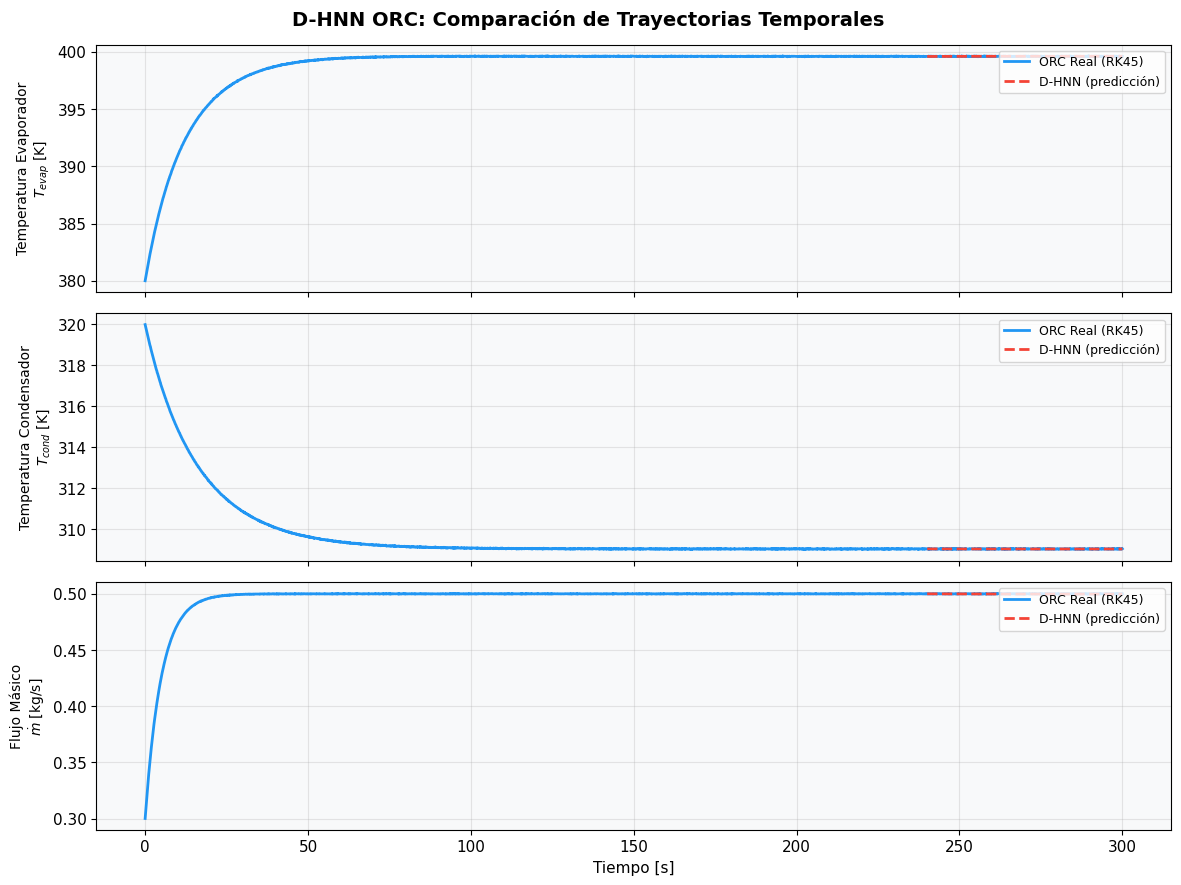

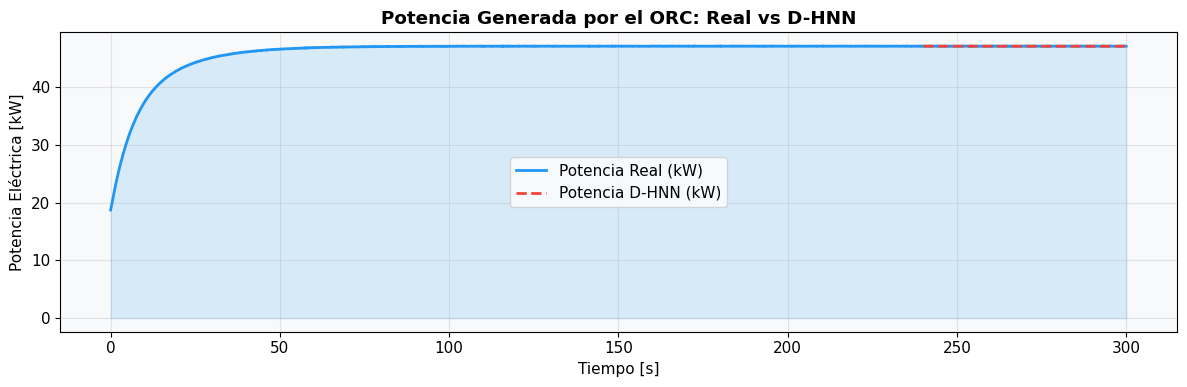

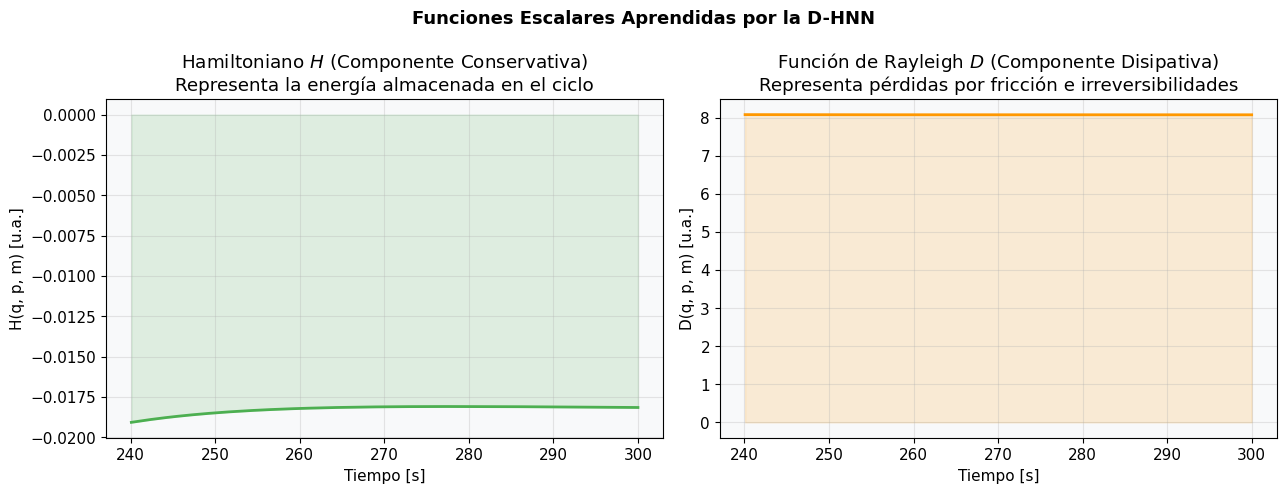

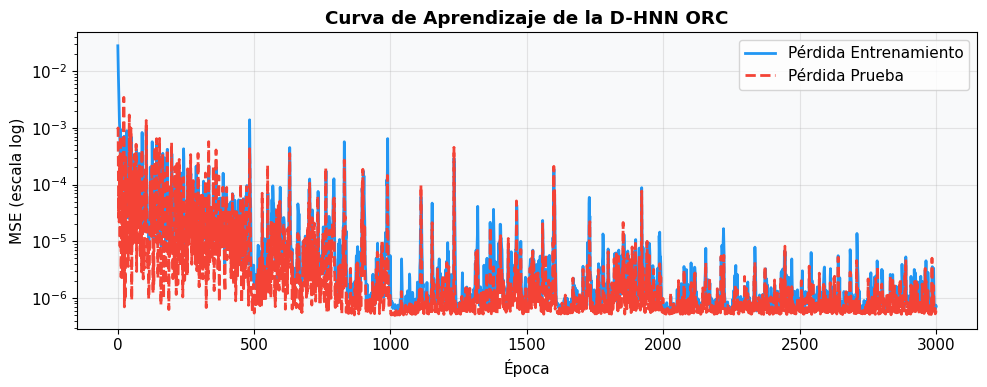

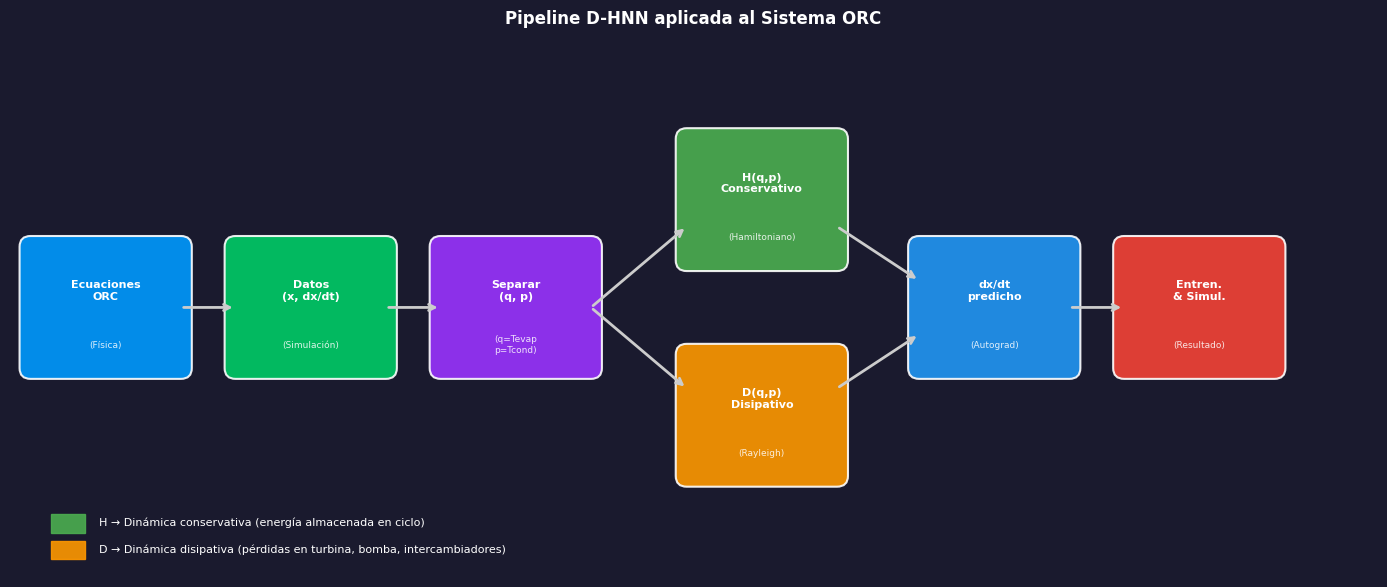

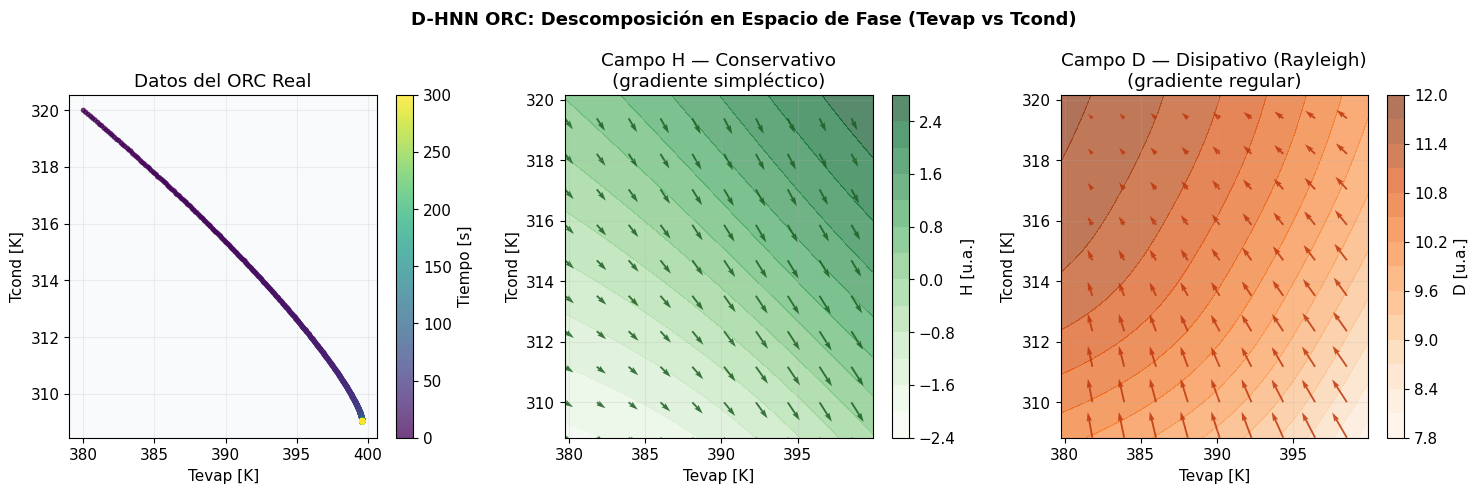

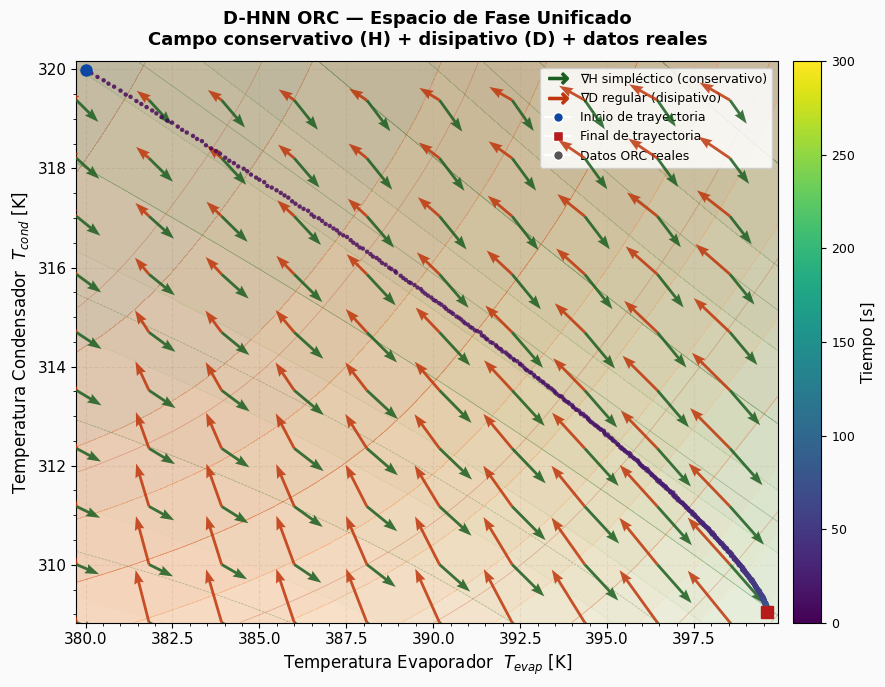

[INFO] Figuras guardadas en: /content/resultados_dhnn_orc

  INTERPRETACIÓN FÍSICA DE LA DESCOMPOSICIÓN D-HNN

  H(q, p, m) — Hamiltoniano (componente conservativa):
  ──────────────────────────────────────────────────────
  → Representa la energía interna almacenada en el ciclo ORC.
  → Captura la dinámica reversible: intercambio de calor ideal
    entre evaporador y condensador.
  → Análogo al Hamiltoniano de un oscilador armónico amortiguado
    en la mecánica clásica.
 
  D(q, p, m) — Función de Rayleigh (componente disipativa):
  ──────────────────────────────────────────────────────────
  → Representa las pérdidas irreversibles del sistema:
    • Irreversibilidades en la turbina (η_turb < 1)
    • Resistencia hidráulica en tuberías y bomba
    • Gradientes de temperatura en intercambiadores reales
  → Su gradiente ∂D/∂q contribuye a la variación de Tevap
    y ∂D/∂p a la variación de Tcond.
  → Directamente relacionada con la disipación de exergía.
 
  La descomposición D-HNN per

In [10]:
# ==============================================================================
# 10. EJECUCIÓN PRINCIPAL
# ==============================================================================

def main():
    """
    Función principal que ejecuta el pipeline completo D-HNN ORC.

    Pasos:
    1. Configurar parámetros físicos del ORC
    2. Generar datos de entrenamiento mediante integración numérica
    3. Normalizar y dividir datos (80/20 entrenamiento/prueba)
    4. Inicializar y entrenar el modelo D-HNN
    5. Simular la evolución temporal con la D-HNN entrenada
    6. Calcular métricas y generar gráficas
    """
    print("="*60)
    print("  D-HNN para Sistema ORC (Organic Rankine Cycle)")
    print("  Sosanya & Greydanus (2022) aplicado a ORC")
    print("="*60)

    # ── Paso 1: Parámetros físicos ────────────────────────────────────────────
    params = ParametrosORC()

    # ── Paso 2: Generación de datos ──────────────────────────────────────────
    datos = generar_datos_orc(params, t_span=(0, 300), n_puntos=3000, ruido=0.005)

    # ── Paso 3: Normalización y división 80/20 ───────────────────────────────
    estados_norm, derivadas_norm, media, escala = normalizar_datos(datos)

    n_total = len(estados_norm)
    n_train = int(0.8 * n_total)

    X_train  = torch.tensor(estados_norm[:n_train],   dtype=torch.float32).to(DISPOSITIVO)
    dX_train = torch.tensor(derivadas_norm[:n_train], dtype=torch.float32).to(DISPOSITIVO)
    X_test   = torch.tensor(estados_norm[n_train:],   dtype=torch.float32).to(DISPOSITIVO)
    dX_test  = torch.tensor(derivadas_norm[n_train:], dtype=torch.float32).to(DISPOSITIVO)

    print(f"\n[INFO] División de datos: {n_train} entrenamiento / {n_total-n_train} prueba")

    # ── Paso 4: Entrenamiento ────────────────────────────────────────────────
    modelo = DHNN_ORC(dim_oculta=128).to(DISPOSITIVO)
    n_parametros = sum(p.numel() for p in modelo.parameters())
    print(f"[INFO] Parámetros del modelo: {n_parametros:,}")

    historial = entrenar_dhnn(
        modelo, X_train, dX_train, X_test, dX_test,
        n_epocas=3000,
        tasa_aprendizaje=1e-3,
        batch_size=128
    )

    # ── Paso 5: Simulación temporal ──────────────────────────────────────────
    print("\n[INFO] Simulando trayectoria con D-HNN entrenada...")

    # Condición inicial (primer punto del conjunto de prueba)
    idx_inicio = n_train
    estado_inicial_norm = estados_norm[idx_inicio]

    t_pred = np.linspace(
        datos['t'][idx_inicio],
        datos['t'][-1],
        len(datos['t']) - idx_inicio
    )

    tray_norm, tray_real, H_traj, D_traj = simular_con_dhnn(
        modelo,
        estado_inicial_norm,
        t_span=(datos['t'][idx_inicio], datos['t'][-1]),
        n_pasos=len(datos['t']) - idx_inicio,
        media=media,
        escala=escala
    )

    # ── Paso 6: Métricas y gráficas ──────────────────────────────────────────
    metricas = calcular_metricas(tray_real, datos, t_pred, params)
    imprimir_metricas(metricas, historial)

    graficar_resultados(
        datos_reales=datos,
        trayectoria_dhnn=tray_real,
        t_integracion=t_pred,
        historial=historial,
        H_traj=H_traj,
        D_traj=D_traj,
        params=params,
        media=media,
        escala=escala,
        modelo=modelo,
        guardar=True
    )

    # ── Interpretación física ────────────────────────────────────────────────
    print("\n" + "="*60)
    print("  INTERPRETACIÓN FÍSICA DE LA DESCOMPOSICIÓN D-HNN")
    print("="*60)
    print("""
  H(q, p, m) — Hamiltoniano (componente conservativa):
  ──────────────────────────────────────────────────────
  → Representa la energía interna almacenada en el ciclo ORC.
  → Captura la dinámica reversible: intercambio de calor ideal
    entre evaporador y condensador.
  → Análogo al Hamiltoniano de un oscilador armónico amortiguado
    en la mecánica clásica.

  D(q, p, m) — Función de Rayleigh (componente disipativa):
  ──────────────────────────────────────────────────────────
  → Representa las pérdidas irreversibles del sistema:
    • Irreversibilidades en la turbina (η_turb < 1)
    • Resistencia hidráulica en tuberías y bomba
    • Gradientes de temperatura en intercambiadores reales
  → Su gradiente ∂D/∂q contribuye a la variación de Tevap
    y ∂D/∂p a la variación de Tcond.
  → Directamente relacionada con la disipación de exergía.

  La descomposición D-HNN permite:
  ──────────────────────────────────────────────────────────
  → Identificar qué fracción de la dinámica es conservative
    (recuperable) vs disipativa (pérdidas permanentes).
  → Responder preguntas contrafactuales: ¿qué potencia se
    generaría si η_turb fuese 0.9 en lugar de 0.8?
  → Detectar degradación de componentes: un aumento en D
    sin cambio en H indica envejecimiento de la turbina.
    """)

    print("[INFO] Pipeline D-HNN ORC completado exitosamente.")
    return modelo, datos, historial, metricas


# ==============================================================================
# PUNTO DE ENTRADA
# ==============================================================================
if __name__ == '__main__':
    modelo, datos, historial, metricas = main()
